In [24]:
%load_ext autoreload
%autoreload 2

# Optional: import common packages
import numpy as np
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
def parse_positions_line_by_line(filename):
    """
    Alternative method: parse line by line looking for x and y values
    (Regex-free version)
    """
    x_coords = []
    y_coords = []
    current_x = None
    current_y = None
    last_x = None
    last_y = None
    
    try:
        thresh = 0.1
        with open(filename, 'r') as file:
            for line_num, line in enumerate(file, 1):
                line = line.strip()
                
                # Look for x coordinate
                if line.startswith('x:'):
                    try:
                        # Split at the first colon, grab the second part, and convert to float
                        current_x = float(line.split(':', 1)[1].strip())
                    except ValueError:
                        pass # Ignore if it can't be converted to a float
                
                # Look for y coordinate
                if line.startswith('y:'):
                    try:
                        current_y = float(line.split(':', 1)[1].strip())
                    except ValueError:
                        pass
                
                # If we have both x and y, save them
                if current_x is not None and current_y is not None:
                    
                    # Filter out the (0.0, 0.0) origin points that cause the plotting glitch
                    if abs(current_x) < 1e-6 and abs(current_y) < 1e-6:
                        current_x = None
                        current_y = None
                        continue

                    if(last_x is None or last_y is None or abs(last_x - current_x) > thresh or abs(last_y - current_y) > thresh):
                        x_coords.append(current_x)
                        y_coords.append(current_y)
                        last_x = current_x
                        last_y = current_y
                        print(f"Position {len(x_coords)}: x={current_x}, y={current_y}")
                        current_x = None
                        current_y = None
                        
                # Reset on separator or new position block
                if line == '--' or line.startswith('position:'):
                    current_x = None
                    current_y = None
                    
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
        return [], []
    except Exception as e:
        print(f"Error reading file: {e}")
        return [], []
    
    return x_coords, y_coords

In [26]:
x, y = parse_positions_line_by_line("circle.txt")

x = np.array(x)
y = np.array(y)

# Filter out points that are exactly (0, 0)
# (Using a small tolerance is safer in case of floating point math)
valid_mask = ~((np.abs(x) < 1e-6) & (np.abs(y) < 1e-6))
# Create a mask that only keeps rows where X is NOT exactly zero
valid_mask = (x != 0.0)

# Apply the mask to both arrays
x = x[valid_mask]
y = y[valid_mask]

print(x)


Position 1: x=4.836278875065236, y=-3.0749895562715133
Position 2: x=-0.0, y=-3.070884842332816
Position 3: x=4.833613736248824, y=-3.069254776778309
Position 4: x=-0.0, y=-3.068452856630851
Position 5: x=4.836094886772118, y=-3.0705711077552307
Position 6: x=-0.0, y=-3.073351385261109
Position 7: x=4.8355734084258355, y=-3.0697379698282723
Position 8: x=-0.0, y=-3.0688983518594637
Position 9: x=4.834191914525153, y=-3.0710131291786578
Position 10: x=-0.0, y=-3.0753353654378035
Position 11: x=4.835870136859074, y=-3.076862688135281
Position 12: x=-0.0, y=-3.0762959048721226
Position 13: x=4.835210200087733, y=-3.0748378725917247
Position 14: x=-0.0, y=-3.073651883984199
Position 15: x=4.834531475767995, y=-3.0709126090950583
Position 16: x=-0.0, y=-3.072324024339887
Position 17: x=4.837963349278028, y=-3.0729560869158155
Position 18: x=-0.0, y=-3.0701013464581406
Position 19: x=4.836781320946184, y=-3.0735968854522775
Position 20: x=-0.0, y=-3.071993106259627
Position 21: x=4.832286695

In [6]:
x = [2.0, 3.0, 4.0, 4.5, 4.6, 4.7, 5, 5.5, 6.35, 6.2, 5.5, 5.2, 5, 4.5, 4, 3, 2, 1, 0.15, -0.2]
y = [0, 0, -.35, -2,  -3, -4, -4.5, -4.5, -4, -3, -2.25, -1.8, -1.06, 0, 0.4, 0.3, 0.2, 0.1, 0, 0]

print(len(x))
print(len(y))

20
20


In [16]:
x = [.35, 2.4, 3.85, 4.5, 4.9, 4.65, 4.5, 5.0, 5.67, 6.0, 5.6, 4.96, 4.3, 2.9, 1.1, 0]
y = [0, 0, 0, -0.5, -2.0, -2.9, -3.85, -4.5, -4.45, -4, -2.5, -1.65, -0.35, 0.1, 0, 0]

print(len(x))
print(len(y))

16
16


In [5]:
# x = [0, 1, 2, 3, 4, 5, 5.5, 5.5, 5.5, 5.5]
# y = [0, 0, 0, 0, 0, 0.5, 2, 3, 5, 6]
# x = [0, 1, 2, 3, 4, 5, 5.5, 5.5, 5.5, 5.5]
# y = [0, 0, 0, 0, 0, 0.5, 2, 3, 5, 6]
print(len(x))
print(len(y))

1554
1554


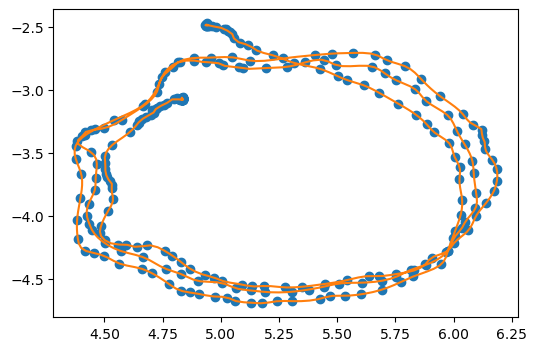

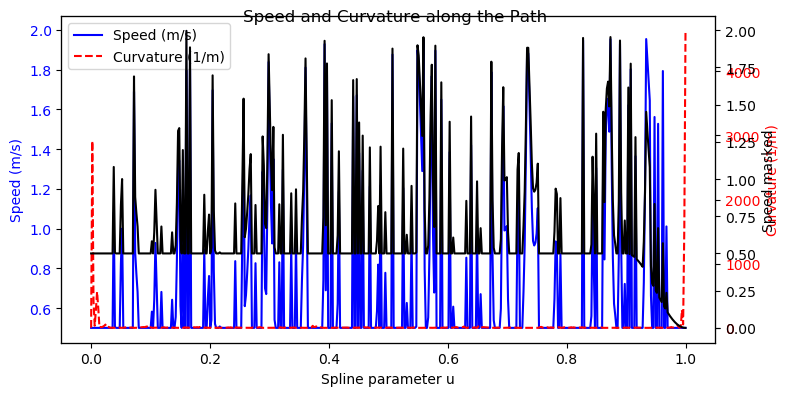

[0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        1.08086899 0.50507692 0.5        0.5        0.5
 0.5        0.82443395 0.99966287 0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 1.6889569  0.87907391 0.77187873 0.6805481  0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.58163359 0.5        0.64152155
 0.92745939 0.72084295 0.5        0.5        0.5        0.68097927
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.64160088 0.5        0.5        0.55496222
 0.83813498 1.32328483 1.34206126 0.61122649 0.5        1.19452494
 0.5        0.5        1.99515336 0.5        0.5        1.88430384
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.8942852

In [27]:
import numpy as np
from scipy.interpolate import splprep, splev
import numpy as np
import matplotlib.pyplot as plt

x = np.array(x)
y = np.array(y)

# Parametric spline preparation (tck = knots, coefficients, degree)
tck, u = splprep([x, y], s=0)  # s=0 for interpolation through all points

# Evaluate the spline at 1000 evenly spaced points between 0 and 1
u_fine = np.linspace(0, 1, 500)
x_smooth, y_smooth = splev(u_fine, tck)

dx_dt, dy_dt = splev(u_fine, tck, der=1)
d2x_dt2, d2y_dt2 = splev(u_fine, tck, der=2)

# Compute curvature at each point
# Curvature formula: kappa = (x'y'' - y'x'') / (x'^2 + y'^2)^(3/2)
curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2)**1.5

# Map curvature to approximate steering angle in degrees
# For simplicity, assume a proportional factor: steering_angle_deg = k * curvature
# This factor depends on wheelbase; here we choose k=180/π to get a rough angle in degrees
steering_angle_deg = np.degrees(curvature)  # crude approximation

angle_points = [0, 20, 40, 90]          # steering angles in degrees
speed_points = [2, 1.5, 1, 0.5]    # corresponding speeds in m/s
speeds = np.interp(steering_angle_deg, angle_points, speed_points)


# Apply velocity ramping at start and end
 # Use 15% of path for ramp-up and 15% for ramp-down

# Create velocity multiplier that goes 0->1->1->0
velocity_multiplier = np.ones_like(u_fine)

# Ramp up at the beginning (smooth using cosine)
# ramp_fraction = 0.15 
# ramp_up_mask = u_fine < ramp_fraction
# velocity_multiplier[ramp_up_mask] = 0.5 * (1 - np.cos(np.pi * u_fine[ramp_up_mask] / ramp_fraction))

ramp_fraction = 0.1
# Ramp down at the end (smooth using cosine)
ramp_down_mask = u_fine > (1 - ramp_fraction)
velocity_multiplier[ramp_down_mask] = 0.5 * (1 + np.cos(np.pi * (u_fine[ramp_down_mask] - (1 - ramp_fraction)) / ramp_fraction))

# Apply the multiplier to get final speeds
speeds_masked = speeds * velocity_multiplier

# Plot original points and the smooth spline
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'o', label='Original points')
plt.plot(x_smooth, y_smooth, '-', label='Smooth spline')

import matplotlib.pyplot as plt

# --- Plot speed and curvature along the path ---
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot speed on the left y-axis
ax1.plot(u_fine, speeds, 'b-', label='Speed (m/s)')
ax1.set_xlabel('Spline parameter u')
ax1.set_ylabel('Speed (m/s)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis for curvature
ax2 = ax1.twinx()
ax2.plot(u_fine, curvature, 'r--', label='Curvature (1/m)')
ax2.set_ylabel('Curvature (1/m)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax3 = ax1.twinx()
ax3.plot(u_fine, speeds_masked, 'black', label='Speed (m/s)')
ax3.set_ylabel('Speed masked', color='black')
ax3.tick_params(axis='y', labelcolor='black')

# Add a title and combined legend
fig.suptitle('Speed and Curvature along the Path')
fig.tight_layout()

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.show()

print(speeds)


In [28]:
print(x_smooth.shape)
print(y_smooth.shape)
print(speeds_masked.shape)

(500,)
(500,)
(500,)


In [29]:
my_dict = {
    "x": x_smooth,
    "y": y_smooth,
    "speed":speeds_masked
}
np.savez("../tracks/circle.npz", **my_dict)

In [9]:
import math as ca



In [10]:
lf = 0.15875			# front tyres from center of gravity [m]
lr = 0.17145			# read tyres from center of gravity [m]
mass = 3.74 			# vehicle mass [kg]
Iz = 0.04712 			# moment of inertia [kgm^2]

p = [15.0, 15.0, 1.0, 1.0, 0.8, 0.8, 0.02, 0.001, 1.0, 0.05]
[-1.18283379e+01, 8.44133197e+00, -3.13430549e+00, 1.53994208e+00, 0.00000000e+00, 3.26238076e-01, 5.25505427e-03, 7.77642316e-02]
[-1.19038986e+01, 8.92304783e+00, -3.11663364e+00, 1.52242383e+00, -1.06785905e-02, 4.00329917e-01, -4.84997183e-01, 2.37764232e-01]
[-11.98117875, 9.40228659, -3.09298757, 1.48680442, -0.01992864, 0.55428524, -0.63623164, 0.39776423]
[-12.06018733, 9.87870879, -3.06122893, 1.44897618, -0.0364329, 0.7089282, -0.51780964, 0.4189]
[-12.14147115, 10.35216898, -3.02271471, 1.42140246, -0.06160558, 0.82595658, -0.19828905, 0.4189]
[-12.22599324, 10.82249848, -2.97905712, 1.41240511, -0.09298859, 0.91711507, 0.25768354, 0.4189]
[-12.31498457, 11.28944213, -2.93123241, 1.42714999, -0.12910757, 0.99421262, 0.7918575, 0.4189]
[-12.4098133, 11.75267232, -2.87973969, 1.46812999, -0.16941979, 1.0648714, 1.35421557, 0.4189]
[-12.5118703, 12.21180682, -2.82476705, 1.53559901, -0.21386682, 1.13409634, 1.90413766, 0.4189]
[-12.62247508, 12.66642565, -2.76629805, 1.62805282, -0.26260107, 1.20518069, 2.41090683, 0.4189]

[-12.62247508,
 12.66642565,
 -2.76629805,
 1.62805282,
 -0.26260107,
 1.20518069,
 2.41090683,
 0.4189]

In [37]:
# alphaf =  x[7] - ca.atan2(x[5] * lf + x[4], x[3])
# alphar =  ca.atan2(x[5] * lr - x[4], x[3])
# #arctan(omega * lr - vy, vx)



# Frx = mass * (x[6] * p[8]  -  p[9] * x[3]) - p[6] - p[7] * x[3] * x[3]
# Ffy = p[4] * ca.sin(p[2] * ca.atan(p[0] * alphaf))
# Fry = p[5] * ca.sin(p[3] * ca.atan(p[1] * alphar))

# dx0 = (x[3] * ca.cos(x[2])) - (x[4] * ca.sin(x[2])) #xdot
# dx1 = (x[3] * ca.sin(x[2])) + (x[4] * ca.cos(x[2])) #ydot
# dx2 = x[5] #phidot
# dx3 = (Frx - Ffy * ca.sin(x[7])) / mass + x[4] * x[5] #vxdot
# dx4 = (Fry + Ffy * ca.cos(x[7])) / mass - x[3] * x[5] #vydot
# dx5 = (lf * Ffy * ca.cos(x[7]) - lr * Fry) / Iz #omegadot

In [38]:
# print(alphaf, alphar, Frx, Ffy, Fry, dx0, dx1, dx2, dx3, dx4, dx5)

In [ ]:
# (x[5] * lf + x[4])/x[3]

0.04577881322817161